In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
# Helper for anchor time localizing to 11am, then UTC, then naive
def set_anchor_time_local_11am(series: pd.Series) -> pd.Series:
    """
    Convert a date-like series to ~11:00 AM America/Los_Angeles,
    then convert to UTC and drop timezone.
    """
    s = pd.to_datetime(series, errors="coerce")
    s = s.dt.tz_localize(None)
    s = s.dt.floor("D") + pd.Timedelta(hours=11)
    s = s.dt.tz_localize("America/Los_Angeles")
    s = s.dt.tz_convert("UTC").dt.tz_localize(None)
    return s


VALID_SITES = list(
    {
        96: ["11482500"],
        12103: ["11481200"],
        92: ["11469000"],
        84: ["11468000"],
        # 77: ["11467553", "11467510"],
        # 72: ["11467000", "11467200"],
        13057: ["11162570"],
        2138: ["11162500"],
        56: ["11161000"],
        57: ["11160000"],
        51: ["11159500"],
        50: ["11152500"],
        48: ["11143250"],
        33: ["11140585"],
        32: ["11136100"],
        31: ["11134000"],
        # 28: ["11120000", "11119940", "11120500", "11120520"],
        # 27: ["11119770", "11119750", "11119745"],
        22: ["11119500"],
        21: ["11118500"],
        # 20: ["11109000", "11113000", "11113500"],
        # 17: ["11046325", "11046360", "11046300"],
        16: ["11046100"],
        15: ["11046000"],
        14: ["11042000"],
        11: ["11023340"],
    }.keys()
)

preds_all = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/merged_all_regions_timeseries_preds.csv"
)
preds_all["date"] = pd.to_datetime(preds_all["date"], errors="coerce")
preds_all["acquired"] = pd.to_datetime(preds_all["acquired"], errors="coerce", utc=True)
preds = preds_all[preds_all.y_pred_unsure == 0].copy()
preds = preds[preds.region.isin(VALID_SITES)].copy()

preds["anchor_time"] = set_anchor_time_local_11am(preds.date)

len(preds)
preds.head()

,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,p_closed,p_open,anchor_time
1,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.013752,0.986248,2017-02-01 19:00:00
3,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000013,0.999987,2017-02-25 19:00:00
4,11,2017-03-03,1,0,2017-03-03 17:47:32+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000008,0.999992,2017-03-03 19:00:00
5,11,2017-03-14,1,0,2017-03-14 17:46:23+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000116,0.999884,2017-03-14 18:00:00
6,11,2017-04-05,1,0,2017-04-05 17:41:06.666666752+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,0.0,0.992138,0.007862,2017-04-05 18:00:00


In [5]:
features = pd.read_parquet(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/merged_all_regions_timeseries_preds_hazard_anchors_feature_table.parquet"
)
features["year"] = features.anchor_time.dt.year
features.head()

,region,anchor_time,horizon_days,event_y,censored,time_to_closure_days,p_open_anchor,linked_event_time,linked_event_midpoint_time,linked_closure_score,...,physics_index_wave_forcing_max_over_flow_forcing_min_fwd_14d,physics_index_wave_forcing_cross_mean_over_flow_forcing_mean_fwd_14d,physics_index_wave_forcing_cross_mean_over_flow_forcing_min_fwd_14d,physics_index_wave_forcing_cross_max_over_flow_forcing_mean_fwd_14d,physics_index_wave_forcing_cross_max_over_flow_forcing_min_fwd_14d,physics_index_wave_forcing_along_mean_over_flow_forcing_mean_fwd_14d,physics_index_wave_forcing_along_mean_over_flow_forcing_min_fwd_14d,physics_index_wave_forcing_along_max_over_flow_forcing_mean_fwd_14d,physics_index_wave_forcing_along_max_over_flow_forcing_min_fwd_14d,year
0,11,2017-02-01 19:00:00,3,NaN,True,NaN,0.986248,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
1,11,2017-02-01 19:00:00,7,NaN,True,NaN,0.986248,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
2,11,2017-02-01 19:00:00,14,NaN,True,NaN,0.986248,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
3,11,2017-02-25 19:00:00,3,NaN,True,NaN,0.999987,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
4,11,2017-02-25 19:00:00,7,0.0,False,NaN,0.999987,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017


In [6]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1. prepare 7-day dataset
# -------------------------

df = features.copy()

mask = (df["censored"] == False) & (df["horizon_days"] == 7)
cs = [c for c in df.columns if "14d" in c and "coverage" in c]
for c in cs:
    mask &= df[c] > 0.9

df = df[mask].copy()

# Keep only rows with labels
df = df[df["event_y"].isin([0, 1])].copy()
df["event_y"] = df["event_y"].astype(int)

print("Rows:", len(df))
print("Positive rate:", df["event_y"].mean())
print("Regions:", df["region"].nunique())

Rows: 4684
Positive rate: 0.07707087959009394
Regions: 20


In [37]:
import pandas as pd
import patsy
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM


def find_best_threshold(y_true, p_pred, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_t = None
    best_score = -np.inf

    for t in grid:
        y_hat = (p_pred >= t).astype(int)
        score = balanced_accuracy_score(y_true, y_hat)
        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score


def _safe_metrics(y_true, p_pred):
    out = {}
    try:
        out["roc_auc"] = roc_auc_score(y_true, p_pred)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y_true, p_pred)
    except Exception:
        out["pr_auc"] = np.nan

    try:
        out["brier"] = brier_score_loss(y_true, p_pred)
    except Exception:
        out["brier"] = np.nan

    return out


def _build_sklearn_model(feature_cols, use_region_intercept=False, class_weight=None):
    transformers = [
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            feature_cols,
        )
    ]

    if use_region_intercept:
        transformers.append(
            (
                "region",
                OneHotEncoder(handle_unknown="ignore"),
                ["region"],
            )
        )

    preprocessor = ColumnTransformer(transformers=transformers)

    model = Pipeline(
        [
            ("preprocessor", preprocessor),
            (
                "logit",
                LogisticRegression(
                    max_iter=2000,
                    class_weight=class_weight,
                ),
            ),
        ]
    )
    return model


def _fit_predict_random_intercept(train_df, test_df, feature_cols):
    """
    Random intercept logistic model using statsmodels BinomialBayesMixedGLM.

    We standardize numeric predictors using train statistics, then fit:

        event_y ~ feature_1 + ... + feature_k
        + (1 | region)

    Returns:
        fitted_result, p_train, p_test, standardized_train_df, standardized_test_df
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Impute + scale manually using train stats only
    means = {}
    stds = {}
    medians = {}

    for col in feature_cols:
        med = train_df[col].median()
        train_df[col] = train_df[col].fillna(med)
        test_df[col] = test_df[col].fillna(med)

        mu = train_df[col].mean()
        sd = train_df[col].std()

        if pd.isna(sd) or sd == 0:
            sd = 1.0

        means[col] = mu
        stds[col] = sd
        medians[col] = med

        train_df[col] = (train_df[col] - mu) / sd
        test_df[col] = (test_df[col] - mu) / sd

    fixed_formula = "event_y ~ " + " + ".join(feature_cols)
    vc_formulas = {"region_intercept": "0 + C(region)"}

    model = BinomialBayesMixedGLM.from_formula(
        fixed_formula,
        vc_formulas,
        train_df,
    )
    result = model.fit_vb()

    # Build fixed-effect design matrices on train/test using patsy
    rhs_formula = fixed_formula.split("~", 1)[1].strip()

    train_exog = patsy.dmatrix(
        rhs_formula,
        train_df,
        return_type="dataframe",
    )
    test_exog = patsy.dmatrix(
        rhs_formula,
        test_df,
        return_type="dataframe",
    )

    # Align columns in case patsy changes order
    test_exog = test_exog.reindex(columns=train_exog.columns, fill_value=0.0)

    # Fixed effects
    fe_params = np.asarray(result.fe_mean)

    # Random intercept posterior means
    # vc names align with C(region)[...]
    vc_names = model.vcp_names if hasattr(model, "vcp_names") else None
    vc_mean = np.asarray(result.vc_mean)

    region_effect_map = {}
    if hasattr(model, "vc_names"):
        for name, val in zip(model.vc_names, vc_mean):
            # name looks like 'C(region)[12]'
            region_effect_map[name] = val

    def _region_re(train_subdf):
        vals = []
        for r in train_subdf["region"].astype(str):
            key = f"C(region)[{r}]"
            vals.append(region_effect_map.get(key, 0.0))
        return np.asarray(vals)

    # Linear predictor = X beta + random intercept
    lin_train = np.asarray(train_exog @ fe_params) + _region_re(train_df)
    lin_test = np.asarray(test_exog @ fe_params) + _region_re(test_df)

    p_train = 1.0 / (1.0 + np.exp(-lin_train))
    p_test = 1.0 / (1.0 + np.exp(-lin_test))

    return result, p_train, p_test, train_df, test_df


def fit_and_eval_logit_with_region_intercept(
    train_df,
    test_df,
    feature_cols,
    model_name,
    region_mode="none",  # "none", "fixed", "random"
    class_weight=None,
):
    """
    Fit and evaluate logistic models in three modes:

    region_mode="none"
        Plain pooled logistic regression.

    region_mode="fixed"
        Region intercept via one-hot encoded region.

    region_mode="random"
        Random intercept by region via statsmodels BinomialBayesMixedGLM.

    Notes
    -----
    - For region_mode="fixed" and especially "random", performance is most
      meaningful when train and test share regions.
    - With held-out regions, fixed/random intercepts cannot help much for
      unseen regions.
    """
    y_train = train_df["event_y"].astype(int).copy()
    y_test = test_df["event_y"].astype(int).copy()

    if region_mode not in {"none", "fixed", "random"}:
        raise ValueError("region_mode must be one of: 'none', 'fixed', 'random'")

    if region_mode in {"none", "fixed"}:
        use_region_intercept = region_mode == "fixed"
        input_cols = feature_cols + (["region"] if use_region_intercept else [])

        X_train = train_df[input_cols].copy()
        X_test = test_df[input_cols].copy()

        model = _build_sklearn_model(
            feature_cols=feature_cols,
            use_region_intercept=use_region_intercept,
            class_weight=class_weight,
        )
        model.fit(X_train, y_train)

        p_train = model.predict_proba(X_train)[:, 1]
        p_test = model.predict_proba(X_test)[:, 1]

    else:
        model, p_train, p_test, train_std_df, test_std_df = _fit_predict_random_intercept(
            train_df=train_df,
            test_df=test_df,
            feature_cols=feature_cols,
        )

    # 0.5 threshold, mostly for reference
    m_train_05 = (p_train >= 0.5).astype(int)
    m_test_05 = (p_test >= 0.5).astype(int)

    # Best threshold selected on train only
    best_t_train, best_bal_acc_train = find_best_threshold(y_train, p_train)
    m_test_best_train_t = (p_test >= best_t_train).astype(int)
    test_bal_acc_at_train_best_t = balanced_accuracy_score(y_test, m_test_best_train_t)

    # Optimistic upper bound on test
    best_t_test, best_bal_acc_test = find_best_threshold(y_test, p_test)

    train_metrics = _safe_metrics(y_train, p_train)
    test_metrics = _safe_metrics(y_test, p_test)

    results = {
        "model": model_name,
        "features": feature_cols,
        "region_mode": region_mode,
        "class_weight": class_weight,
        "train_roc_auc": train_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "train_pr_auc": train_metrics["pr_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "train_bal_acc_0.5": balanced_accuracy_score(y_train, m_train_05),
        "test_bal_acc_0.5": balanced_accuracy_score(y_test, m_test_05),
        "best_threshold_train": best_t_train,
        "train_bal_acc_best_threshold": best_bal_acc_train,
        "test_bal_acc_at_train_best_threshold": test_bal_acc_at_train_best_t,
        "best_threshold_test_optimistic": best_t_test,
        "test_bal_acc_best_threshold_optimistic": best_bal_acc_test,
        "train_pred_positive_rate_0.5": m_train_05.mean(),
        "test_pred_positive_rate_0.5": m_test_05.mean(),
        "test_pred_positive_rate_train_best_t": m_test_best_train_t.mean(),
        "train_event_rate": y_train.mean(),
        "test_event_rate": y_test.mean(),
    }

    return model, results, p_test

In [22]:
# -------------------------
# 4. define the 3 baselines
# -------------------------

baseline_specs = [
    # {
    #     "name": "flow_max_14d",
    #     "features": ["log_flow_forcing_max_fwd_14d"],
    # },
    # {
    #     "name": "flow_min_14d",
    #     "features": ["log_flow_forcing_min_fwd_14d"],
    # },
    # {
    #     "name": "flow_mean_14d",
    #     "features": ["log_flow_forcing_mean_fwd_14d"],
    # },
    # {
    #     "name": "wave_max_along",
    #     "features": ["log_wave_forcing_along_max_fwd_14d"],
    # },
    # {
    #     "name": "wave_max_cross",
    #     "features": ["log_wave_forcing_cross_max_fwd_14d"],
    # },
    # {
    #     "name": "wave_max",
    #     "features": ["log_wave_forcing_max_fwd_14d"],
    # },
    {
        "name": "p_open",
        "features": ["p_open_anchor"],
    },
]

cols = [c for c in features.columns if "14d" in c and "fwd" in c]
valid_cols = []
for c in cols:
    if f"log_{c}" in cols:
        continue
    if "coverage" in c:
        continue
    if "tide" in c and "range" not in c:
        continue
    if "wave_forcing" in c and "min" in c and "physics" not in c:
        continue
    valid_cols.append(c)

for c in valid_cols:
    baseline_specs.append(
        {
            "name": c,
            "features": [
                c,
            ],
        }
    )

In [23]:
import pandas as pd

selected_features = [
    "tide_range_fwd_14d",
    "physics_index_inst_mean_fwd_14d",
    "physics_index_inst_min_fwd_14d",
    "physics_index_inst_max_fwd_14d",
    "physics_index_cross_inst_mean_fwd_14d",
    "physics_index_cross_inst_min_fwd_14d",
    "physics_index_cross_inst_max_fwd_14d",
    "physics_index_along_inst_mean_fwd_14d",
    "physics_index_along_inst_min_fwd_14d",
    "physics_index_along_inst_max_fwd_14d",
    "log_wave_forcing_mean_fwd_14d",
    "log_wave_forcing_max_fwd_14d",
    "log_wave_forcing_cross_mean_fwd_14d",
    "log_wave_forcing_cross_max_fwd_14d",
    "log_wave_forcing_along_mean_fwd_14d",
    "log_wave_forcing_along_max_fwd_14d",
    "log_flow_forcing_mean_fwd_14d",
    "log_flow_forcing_min_fwd_14d",
    "log_flow_forcing_max_fwd_14d",
    "physics_index_wave_forcing_mean_over_flow_forcing_mean_fwd_14d",
    "physics_index_wave_forcing_mean_over_flow_forcing_min_fwd_14d",
    "physics_index_wave_forcing_max_over_flow_forcing_mean_fwd_14d",
    "physics_index_wave_forcing_max_over_flow_forcing_min_fwd_14d",
    "physics_index_wave_forcing_cross_mean_over_flow_forcing_mean_fwd_14d",
    "physics_index_wave_forcing_cross_mean_over_flow_forcing_min_fwd_14d",
    "physics_index_wave_forcing_cross_max_over_flow_forcing_mean_fwd_14d",
    "physics_index_wave_forcing_cross_max_over_flow_forcing_min_fwd_14d",
    "physics_index_wave_forcing_along_mean_over_flow_forcing_mean_fwd_14d",
    "physics_index_wave_forcing_along_mean_over_flow_forcing_min_fwd_14d",
    "physics_index_wave_forcing_along_max_over_flow_forcing_mean_fwd_14d",
    "physics_index_wave_forcing_along_max_over_flow_forcing_min_fwd_14d",
]


def assign_feature_family(name: str) -> str:
    if name.startswith("tide_"):
        return "tide"
    if name.startswith("log_wave_forcing_cross"):
        return "wave_cross"
    if name.startswith("log_wave_forcing_along"):
        return "wave_along"
    if name.startswith("log_wave_forcing"):
        return "wave_total"
    if name.startswith("log_flow_forcing"):
        return "flow"
    if name.startswith("physics_index_inst"):
        return "inst_total"
    if name.startswith("physics_index_cross_inst"):
        return "inst_cross"
    if name.startswith("physics_index_along_inst"):
        return "inst_along"
    if name.startswith("physics_index_wave_forcing_cross"):
        return "ratio_cross"
    if name.startswith("physics_index_wave_forcing_along"):
        return "ratio_along"
    if name.startswith("physics_index_wave_forcing"):
        return "ratio_total"
    return "other"


feature_groups = {}
for col in selected_features:
    fam = assign_feature_family(col)
    feature_groups.setdefault(fam, []).append(col)

feature_groups

{'tide': ['tide_range_fwd_14d'],
 'inst_total': ['physics_index_inst_mean_fwd_14d',
  'physics_index_inst_min_fwd_14d',
  'physics_index_inst_max_fwd_14d'],
 'inst_cross': ['physics_index_cross_inst_mean_fwd_14d',
  'physics_index_cross_inst_min_fwd_14d',
  'physics_index_cross_inst_max_fwd_14d'],
 'inst_along': ['physics_index_along_inst_mean_fwd_14d',
  'physics_index_along_inst_min_fwd_14d',
  'physics_index_along_inst_max_fwd_14d'],
 'wave_total': ['log_wave_forcing_mean_fwd_14d',
  'log_wave_forcing_max_fwd_14d'],
 'wave_cross': ['log_wave_forcing_cross_mean_fwd_14d',
  'log_wave_forcing_cross_max_fwd_14d'],
 'wave_along': ['log_wave_forcing_along_mean_fwd_14d',
  'log_wave_forcing_along_max_fwd_14d'],
 'flow': ['log_flow_forcing_mean_fwd_14d',
  'log_flow_forcing_min_fwd_14d',
  'log_flow_forcing_max_fwd_14d'],
 'ratio_total': ['physics_index_wave_forcing_mean_over_flow_forcing_mean_fwd_14d',
  'physics_index_wave_forcing_mean_over_flow_forcing_min_fwd_14d',
  'physics_index_wave

In [24]:
def plot_corr_heatmap(
    df: pd.DataFrame,
    cols: list[str],
    title: str,
    method: str = "spearman",
    figsize_scale: float = 0.55,
    annot: bool = False,
):
    sub = df[cols].copy()
    corr = sub.corr(method=method)

    n = len(cols)
    fig_w = max(6, n * figsize_scale)
    fig_h = max(5, n * figsize_scale)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(cols, rotation=90)
    ax.set_yticklabels(cols)
    ax.set_title(f"{title} ({method})")

    if annot:
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return corr

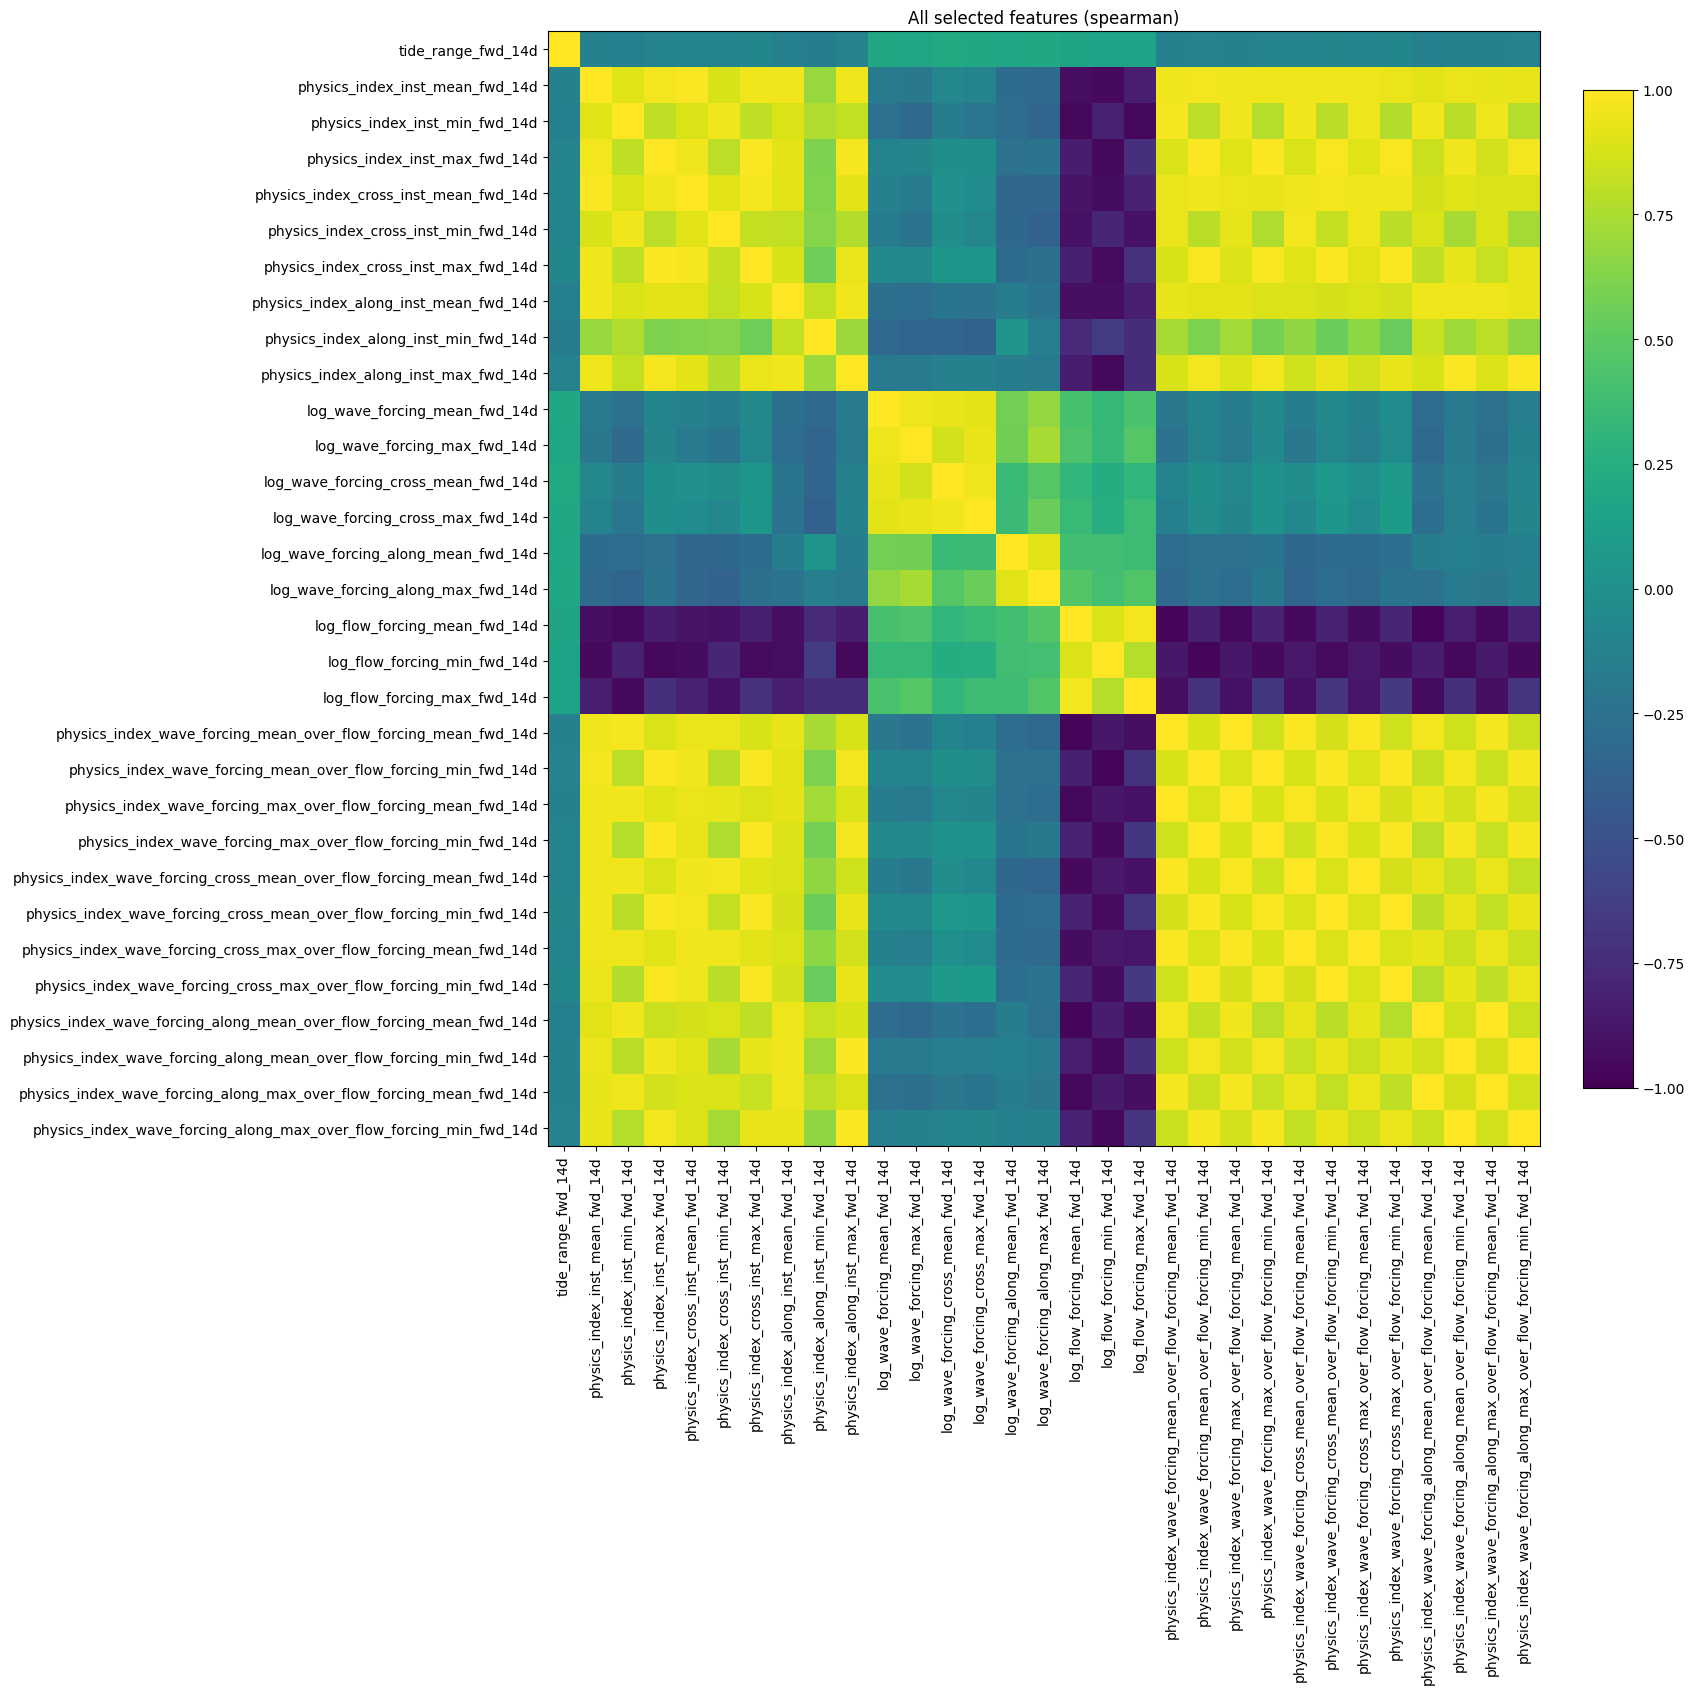

In [25]:
# one overall correlation heatmap
overall_corr = plot_corr_heatmap(
    features,
    selected_features,
    title="All selected features",
    method="spearman",
    annot=False,
)

Skipping tide: only 1 feature


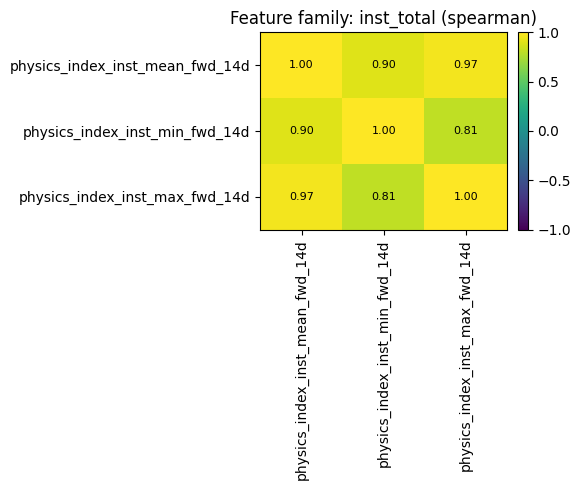

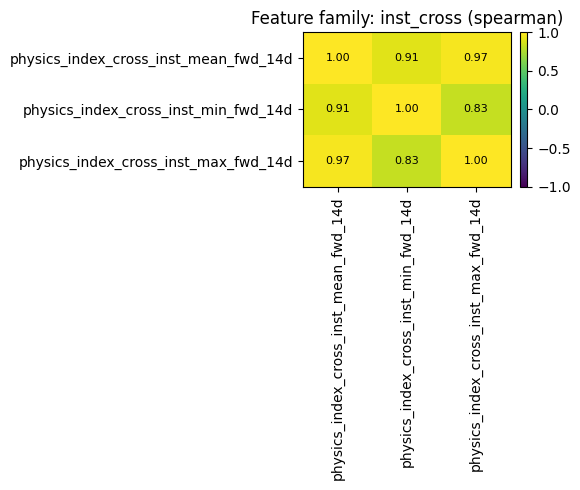

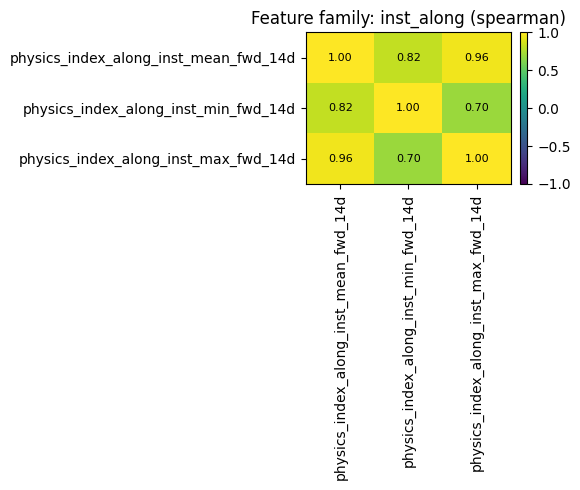

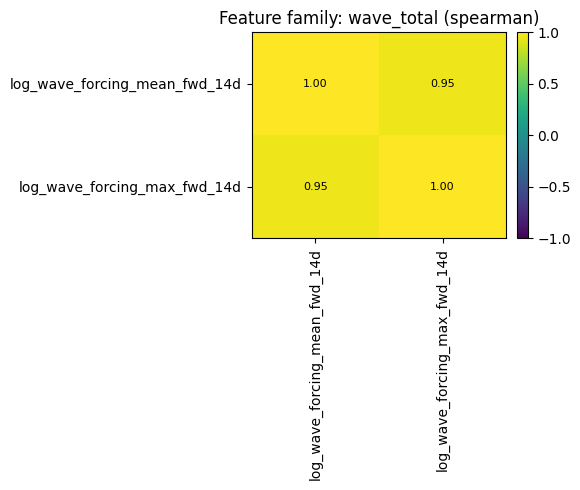

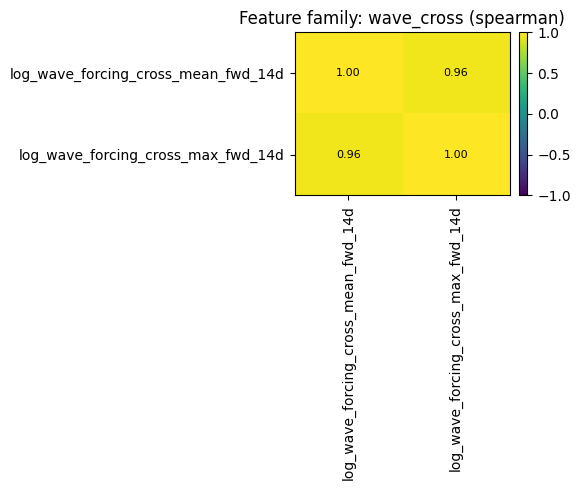

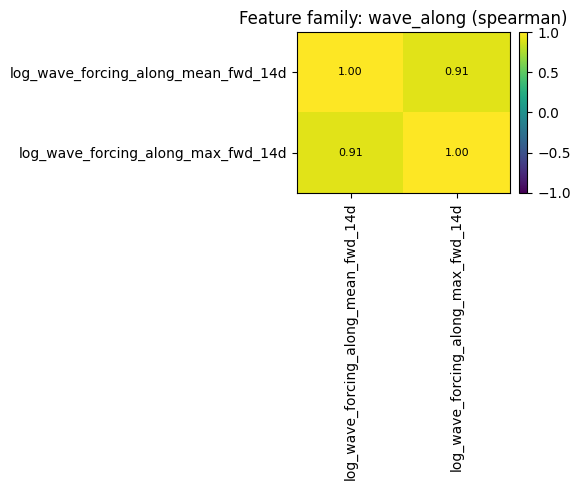

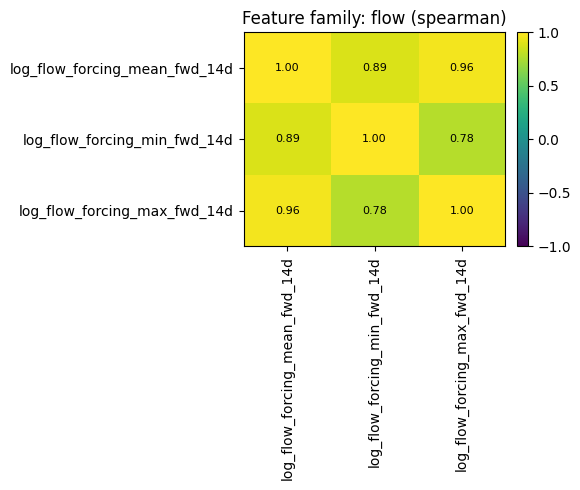

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_25008/378590707.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


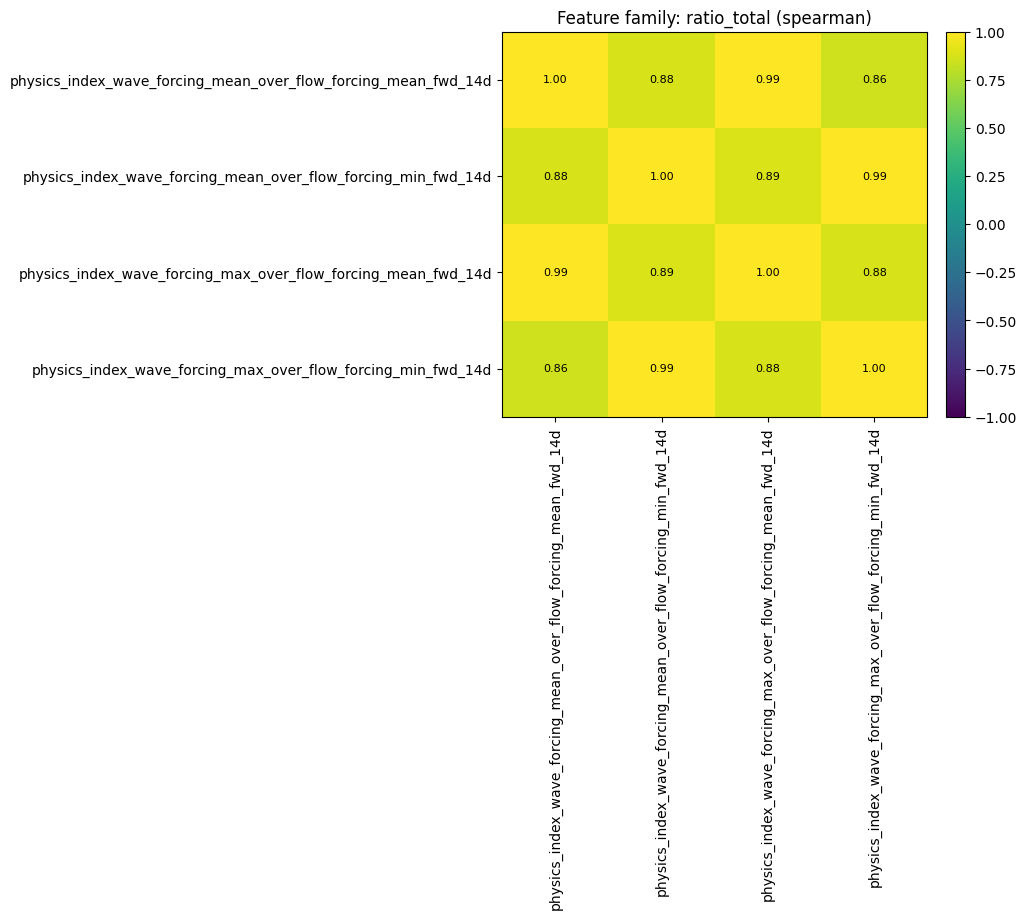

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_25008/378590707.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


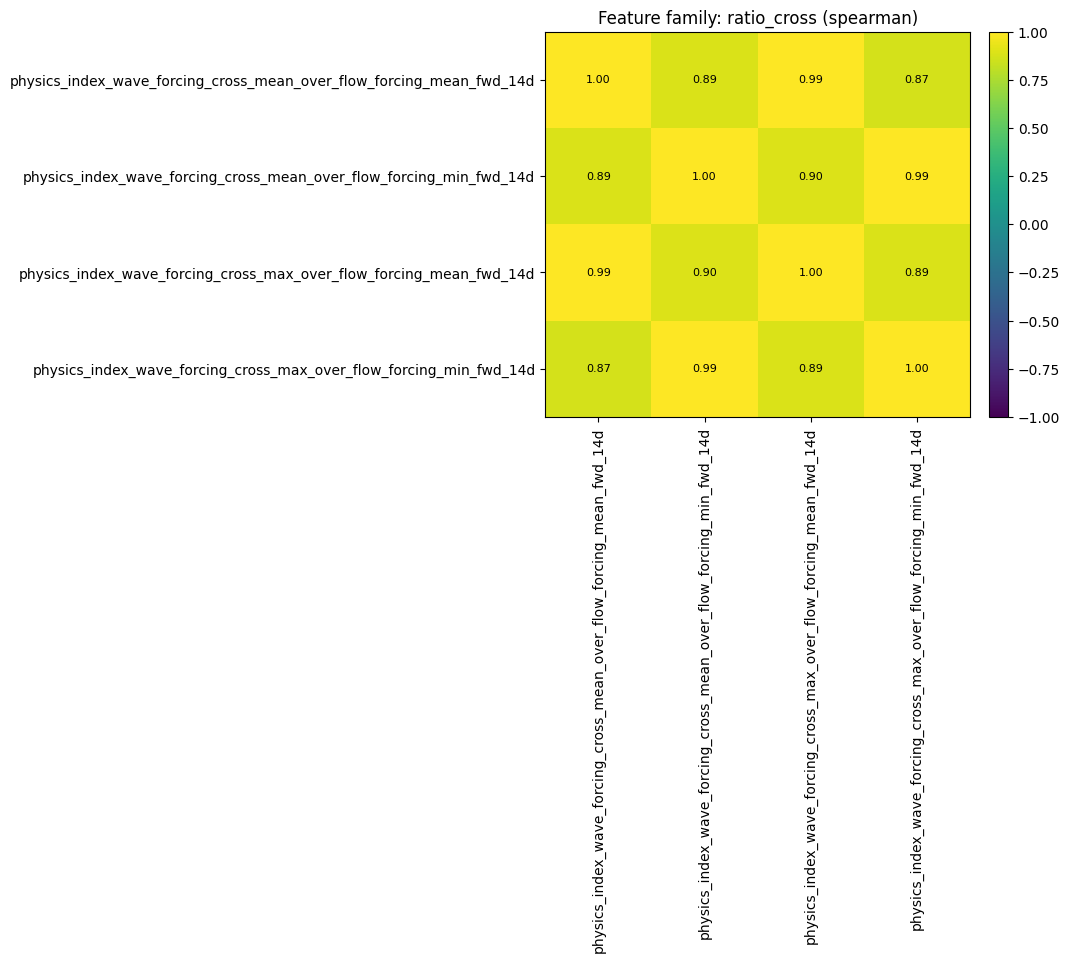

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_25008/378590707.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


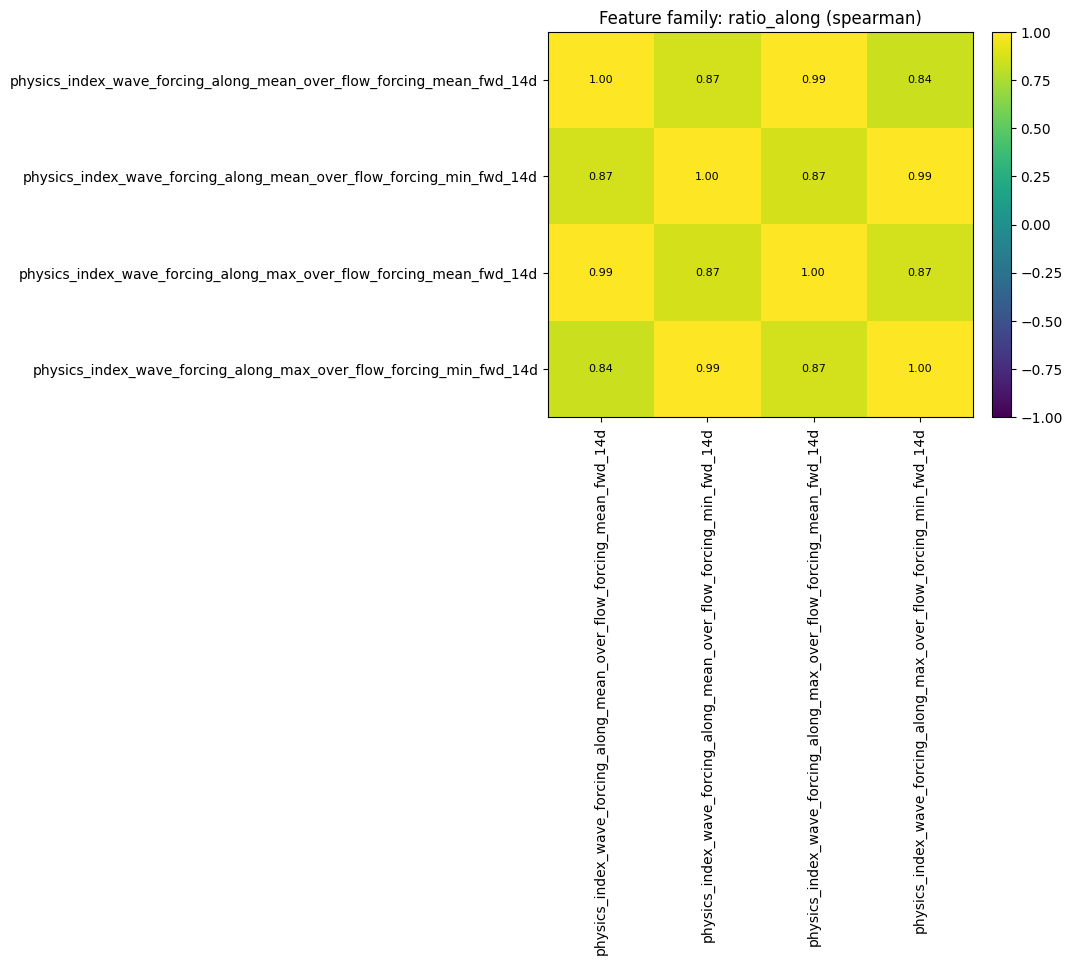

In [26]:
# one heatmap per family
family_corrs = {}

for family, cols in feature_groups.items():
    if len(cols) < 2:
        print(f"Skipping {family}: only {len(cols)} feature")
        continue

    corr = plot_corr_heatmap(
        features,
        cols,
        title=f"Feature family: {family}",
        method="spearman",
        annot=True if len(cols) <= 8 else False,
    )
    family_corrs[family] = corr

In [27]:
def get_top_corr_pairs(corr: pd.DataFrame, min_abs_corr: float = 0.85) -> pd.DataFrame:
    rows = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr.iloc[i, j]
            if abs(val) >= min_abs_corr:
                rows.append(
                    {
                        "feature_1": cols[i],
                        "feature_2": cols[j],
                        # "corr": val,
                        "abs_corr": abs(val),
                    }
                )
    out = pd.DataFrame(rows).sort_values("abs_corr", ascending=False)
    return out.reset_index(drop=True)


top_pairs = get_top_corr_pairs(overall_corr, min_abs_corr=0.85)
top_pairs.head(50)

,feature_1,feature_2,abs_corr
0,physics_index_wave_forcing_cross_mean_over_flo...,physics_index_wave_forcing_cross_max_over_flow...,0.994577
1,physics_index_wave_forcing_mean_over_flow_forc...,physics_index_wave_forcing_max_over_flow_forci...,0.994395
2,physics_index_wave_forcing_mean_over_flow_forc...,physics_index_wave_forcing_max_over_flow_forci...,0.994391
3,physics_index_wave_forcing_cross_mean_over_flo...,physics_index_wave_forcing_cross_max_over_flow...,0.994386
4,physics_index_wave_forcing_along_mean_over_flo...,physics_index_wave_forcing_along_max_over_flow...,0.992762
5,physics_index_wave_forcing_along_mean_over_flo...,physics_index_wave_forcing_along_max_over_flow...,0.992217
6,physics_index_cross_inst_max_fwd_14d,physics_index_wave_forcing_cross_mean_over_flo...,0.990901
7,physics_index_inst_max_fwd_14d,physics_index_cross_inst_max_fwd_14d,0.990510
8,physics_index_wave_forcing_max_over_flow_forci...,physics_index_wave_forcing_cross_max_over_flow...,0.990303
9,physics_index_inst_max_fwd_14d,physics_index_wave_forcing_mean_over_flow_forc...,0.990273


In [38]:
# -------------------------
# 5. train all 3
# -------------------------

trained_models = {}
results_list = []

df_region = df.copy()

train_df_r = df_region[~df_region.year.isin([2024, 2025, 2023])].copy()
test_df_r = df_region[df_region.year.isin([2024, 2025, 2023])].copy()
# train_df_r, test_df_r = train_test_split(
#     df_region,
#     test_size=0.3,
#     random_state=42,
#     stratify=df_region["event_y"],
# )

print("Train rows:", len(train_df_r), "Test rows:", len(test_df_r))
print(
    "Train regions:", train_df_r["region"].nunique(), "Test regions:", test_df_r["region"].nunique()
)
print("Train positive rate:", train_df_r["event_y"].mean())
print("Test positive rate:", test_df_r["event_y"].mean())

cols = [
    "log_flow_forcing_mean_fwd_14d",
    "log_wave_forcing_along_mean_fwd_14d",
    "log_wave_forcing_cross_max_fwd_14d",
    "physics_index_along_inst_min_fwd_14d",
    "physics_index_cross_inst_mean_fwd_14d",
    "physics_index_inst_mean_fwd_14d",
    "tide_range_fwd_14d",
    "p_open_anchor",
]

for spec in cols:
    model_region, results_region, p_test_region = fit_and_eval_logit_with_region_intercept(
        train_df=train_df_r,
        test_df=test_df_r,
        feature_cols=[spec],
        model_name=spec,
        region_mode="none",
    )
    trained_models[spec] = model_region
    results_list.append(results_region)

    model_region, results_region, p_test_region = fit_and_eval_logit_with_region_intercept(
        train_df=train_df_r,
        test_df=test_df_r,
        feature_cols=[spec],
        model_name=spec,
        region_mode="fixed",
    )
    trained_models[spec + "_fixed"] = model_region
    results_list.append(results_region)

    model_region, results_region, p_test_region = fit_and_eval_logit_with_region_intercept(
        train_df=train_df_r,
        test_df=test_df_r,
        feature_cols=[spec],
        model_name=spec,
        region_mode="random",
    )
    trained_models[spec + "_random"] = model_region
    results_list.append(results_region)

results_df = (
    pd.DataFrame(results_list).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
)
results_df.round(3)

Train rows: 3242 Test rows: 1442
Train regions: 20 Test regions: 20
Train positive rate: 0.08945095619987661
Test positive rate: 0.049237170596393896


,model,features,region_mode,class_weight,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc,train_brier,test_brier,...,best_threshold_train,train_bal_acc_best_threshold,test_bal_acc_at_train_best_threshold,best_threshold_test_optimistic,test_bal_acc_best_threshold_optimistic,train_pred_positive_rate_0.5,test_pred_positive_rate_0.5,test_pred_positive_rate_train_best_t,train_event_rate,test_event_rate
0,p_open_anchor,[p_open_anchor],none,None,0.830,0.906,0.349,0.346,0.077,0.045,...,0.08,0.689,0.734,0.08,0.734,0.013,0.005,0.076,0.089,0.049
1,physics_index_cross_inst_mean_fwd_14d,[physics_index_cross_inst_mean_fwd_14d],random,None,0.905,0.843,0.575,0.299,0.055,0.050,...,0.12,0.825,0.820,0.10,0.849,0.030,0.041,0.124,0.089,0.049
2,physics_index_inst_mean_fwd_14d,[physics_index_inst_mean_fwd_14d],random,None,0.901,0.840,0.562,0.296,0.056,0.050,...,0.12,0.822,0.821,0.07,0.839,0.029,0.041,0.123,0.089,0.049
3,physics_index_cross_inst_mean_fwd_14d,[physics_index_cross_inst_mean_fwd_14d],fixed,None,0.895,0.833,0.540,0.281,0.059,0.044,...,0.13,0.821,0.799,0.10,0.811,0.015,0.021,0.136,0.089,0.049
4,log_flow_forcing_mean_fwd_14d,[log_flow_forcing_mean_fwd_14d],random,None,0.889,0.833,0.565,0.295,0.056,0.053,...,0.10,0.818,0.832,0.11,0.839,0.027,0.042,0.171,0.089,0.049
5,physics_index_inst_mean_fwd_14d,[physics_index_inst_mean_fwd_14d],fixed,None,0.891,0.832,0.534,0.281,0.059,0.044,...,0.13,0.817,0.771,0.10,0.819,0.015,0.022,0.132,0.089,0.049
6,log_flow_forcing_mean_fwd_14d,[log_flow_forcing_mean_fwd_14d],fixed,None,0.880,0.824,0.532,0.273,0.060,0.046,...,0.12,0.819,0.790,0.09,0.813,0.013,0.024,0.180,0.089,0.049
7,physics_index_along_inst_min_fwd_14d,[physics_index_along_inst_min_fwd_14d],fixed,None,0.854,0.785,0.466,0.197,0.064,0.049,...,0.11,0.764,0.709,0.06,0.744,0.009,0.019,0.250,0.089,0.049
8,physics_index_along_inst_min_fwd_14d,[physics_index_along_inst_min_fwd_14d],random,None,0.857,0.782,0.474,0.194,0.063,0.055,...,0.18,0.767,0.676,0.15,0.740,0.019,0.037,0.130,0.089,0.049
9,p_open_anchor,[p_open_anchor],fixed,None,0.853,0.722,0.378,0.193,0.068,0.052,...,0.07,0.769,0.618,0.04,0.667,0.016,0.008,0.508,0.089,0.049


In [36]:
# -------------------------
# 5. train all 3
# -------------------------

trained_models = {}
results_list = []

df_region = df.copy()

train_df_r = df_region[~df_region.year.isin([2024, 2025, 2023])].copy()
test_df_r = df_region[df_region.year.isin([2024, 2025, 2023])].copy()
# train_df_r, test_df_r = train_test_split(
#     df_region,
#     test_size=0.3,
#     random_state=42,
#     stratify=df_region["event_y"],
# )

print("Train rows:", len(train_df_r), "Test rows:", len(test_df_r))
print(
    "Train regions:", train_df_r["region"].nunique(), "Test regions:", test_df_r["region"].nunique()
)
print("Train positive rate:", train_df_r["event_y"].mean())
print("Test positive rate:", test_df_r["event_y"].mean())

for spec in baseline_specs:
    model_region, results_region, p_test_region = fit_and_eval_logit_with_region_intercept(
        train_df=train_df_r,
        test_df=test_df_r,
        feature_cols=spec["features"],
        model_name=spec["name"],
        use_region_intercept=True,
    )
    trained_models[spec["name"]] = model_region
    results_list.append(results_region)

    model_region, results_region, p_test_region = fit_and_eval_logit_with_region_intercept(
        train_df=train_df_r,
        test_df=test_df_r,
        feature_cols=spec["features"],
        model_name=spec["name"],
        use_region_intercept=False,
    )
    trained_models[spec["name"]] = model_region
    results_list.append(results_region)

results_df = (
    pd.DataFrame(results_list).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
)
results_df.round(3).head(20)

Train rows: 3242 Test rows: 1442
Train regions: 20 Test regions: 20
Train positive rate: 0.08945095619987661
Test positive rate: 0.049237170596393896


,model,features,use_region_intercept,class_weight,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc,best_threshold_train,train_bal_acc_best_threshold,test_bal_acc_at_train_best_threshold,best_threshold_test_optimistic,test_bal_acc_best_threshold_optimistic,test_pred_positive_rate_train_best_t
0,p_open,[p_open_anchor],False,None,0.830,0.906,0.349,0.346,0.08,0.689,0.734,0.08,0.734,0.076
1,physics_index_wave_forcing_cross_max_over_flow...,[physics_index_wave_forcing_cross_max_over_flo...,True,None,0.886,0.843,0.545,0.296,0.11,0.816,0.819,0.11,0.819,0.169
2,physics_index_wave_forcing_max_over_flow_forci...,[physics_index_wave_forcing_max_over_flow_forc...,True,None,0.882,0.840,0.535,0.294,0.12,0.815,0.797,0.10,0.817,0.153
3,physics_index_wave_forcing_cross_mean_over_flo...,[physics_index_wave_forcing_cross_mean_over_fl...,True,None,0.887,0.837,0.555,0.295,0.13,0.816,0.811,0.10,0.826,0.141
4,physics_index_wave_forcing_mean_over_flow_forc...,[physics_index_wave_forcing_mean_over_flow_for...,True,None,0.884,0.835,0.549,0.292,0.13,0.814,0.791,0.11,0.828,0.137
5,physics_index_cross_inst_mean_fwd_14d,[physics_index_cross_inst_mean_fwd_14d],True,None,0.895,0.833,0.540,0.281,0.13,0.821,0.799,0.10,0.811,0.136
6,physics_index_cross_inst_max_fwd_14d,[physics_index_cross_inst_max_fwd_14d],True,None,0.886,0.833,0.498,0.268,0.09,0.813,0.803,0.09,0.803,0.212
7,physics_index_inst_mean_fwd_14d,[physics_index_inst_mean_fwd_14d],True,None,0.891,0.832,0.534,0.281,0.13,0.817,0.771,0.10,0.819,0.132
8,physics_index_wave_forcing_cross_max_over_flow...,[physics_index_wave_forcing_cross_max_over_flo...,True,None,0.879,0.831,0.459,0.254,0.10,0.814,0.802,0.08,0.803,0.200
9,physics_index_inst_min_fwd_14d,[physics_index_inst_min_fwd_14d],True,None,0.875,0.830,0.542,0.283,0.14,0.807,0.810,0.13,0.831,0.144


In [35]:
results_df.iloc[1].model

'physics_index_wave_forcing_cross_max_over_flow_forcing_mean_fwd_14d'

In [29]:
keepers = []
review = []
for k, keys in feature_groups.items():
    mm = results_df[results_df.model.isin(keys)].iloc[0].model
    keepers.append(mm)
    review.append((k, mm))

for k, mm in review:
    values = feature_groups[k]
    if len(values) < 2:
        continue
    sub = df[values].copy()
    corr = sub.corr(method="spearman")
    idx = values.index(mm)
    to_add = np.where(corr[mm].to_numpy() < 0.9)[0]
    if not len(to_add):
        continue
    for i in to_add:
        keepers.append(values[i])

skip = [
    "physics_index_wave_forcing_max_over_flow_forcing_mean_fwd_14d",
    # "physics_index_cross_inst_max_fwd_14d",
    "physics_index_inst_max_fwd_14d",
    "physics_index_along_inst_mean_fwd_14d",
    "physics_index_along_inst_max_fwd_14d",
    "physics_index_wave_forcing_along_max_over_flow_forcing_mean_fwd_14d",
    "log_wave_forcing_mean_fwd_14d",
    "log_flow_forcing_min_fwd_14d",
    "physics_index_wave_forcing_cross_max_over_flow_forcing_mean_fwd_14d",
]
keepers = [k for k in keepers if k not in skip]
len(keepers), sorted(keepers)

(7,
 ['log_flow_forcing_mean_fwd_14d',
  'log_wave_forcing_along_mean_fwd_14d',
  'log_wave_forcing_cross_max_fwd_14d',
  'physics_index_along_inst_min_fwd_14d',
  'physics_index_cross_inst_mean_fwd_14d',
  'physics_index_inst_mean_fwd_14d',
  'tide_range_fwd_14d'])

In [ ]:
# one overall correlation heatmap
overall_corr2 = plot_corr_heatmap(
    df,
    keepers,
    title="All selected features",
    method="spearman",
    annot=False,
)
top_pairs = get_top_corr_pairs(overall_corr2, min_abs_corr=0.0)
top_pairs

In [ ]:
import seaborn as sns

for i in range(len(keepers)):
    for j in range(i + 1, len(keepers)):
        plt.figure()
        sns.scatterplot(x=df[keepers[i]], y=df[keepers[j]], hue=df["event_y"], alpha=0.2)

In [ ]:
keepers

In [ ]:
baseline_specs2 = [
    {
        "name": "p_open",
        "features": ["p_open_anchor"],
    },
    {
        "name": "physics_index_cross_inst_max_fwd_14d",
        "features": ["physics_index_cross_inst_max_fwd_14d"],
    },
    {
        "name": "physics_index_along_inst_min_fwd_14d",
        "features": ["physics_index_along_inst_min_fwd_14d"],
    },
    {
        "name": "physics2",
        "features": [
            "physics_index_along_inst_min_fwd_14d",
            "physics_index_cross_inst_max_fwd_14d",
        ],
    },
    {
        "name": "log_wave_forcing_cross_mean_fwd_14d",
        "features": ["log_wave_forcing_cross_mean_fwd_14d"],
    },
    {
        "name": "wave_flow",
        "features": ["log_flow_forcing_max_fwd_14d", "log_wave_forcing_cross_mean_fwd_14d"],
    },
    {
        "name": "physicis+tide",
        "features": [
            "tide_range_fwd_14d",
            "physics_index_cross_inst_max_fwd_14d",
            "physics_index_along_inst_min_fwd_14d",
        ],
    },
]

# -------------------------
# 5. train all 3
# -------------------------

trained_models2 = {}
results_list2 = []

for spec in baseline_specs2:
    model, results, p_test = fit_and_eval_logit(
        train_df=train_df,
        test_df=test_df,
        feature_cols=spec["features"],
        model_name=spec["name"],
    )
    trained_models2[spec["name"]] = model
    results_list2.append(results)

results_df2 = (
    pd.DataFrame(results_list2).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
)
results_df2.round(3)

In [ ]:
# -------------------------
# 6. inspect coefficients
# -------------------------


def get_logit_coefficients(pipeline, feature_cols):
    coef = pipeline.named_steps["logit"].coef_[0]
    intercept = pipeline.named_steps["logit"].intercept_[0]
    out = pd.DataFrame(
        {
            "feature": feature_cols,
            "coef": coef,
        }
    )
    return intercept, out


for spec in baseline_specs2:
    intercept, coef_df = get_logit_coefficients(trained_models2[spec["name"]], spec["features"])
    print("\n", spec["name"])
    print("intercept:", intercept)
    print(coef_df)

In [ ]:
import matplotlib.pyplot as plt


def plot_event_rate_by_quantile(df, predictor, n_bins=10):
    sub = df[[predictor, "event_y"]].dropna().copy()
    sub["bin"] = pd.qcut(sub[predictor], q=n_bins, duplicates="drop")
    agg = (
        sub.groupby("bin", observed=False)
        .agg(
            predictor_mean=(predictor, "mean"),
            event_rate=("event_y", "mean"),
            n=("event_y", "size"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(agg["predictor_mean"], agg["event_rate"], marker="o")
    ax.set_xlabel(predictor)
    ax.set_ylabel("Closure event rate")
    ax.set_title(f"Event rate vs {predictor}")
    plt.show()

    return agg

In [ ]:
plot_event_rate_by_quantile(df, "physics_index_along_inst_min_fwd_14d")
plot_event_rate_by_quantile(df, "physics_index_cross_inst_min_fwd_14d")
# plot_event_rate_by_quantile(df, "physics_index_14d")
# plot_event_rate_by_quantile(df, "interaction_14d")